[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

### Lecture 04 Hypothesis test
## - Non-Parametric tests:
- Wilcoxon rank-sum
- Kruskal–Wallis
- Kolmogorov–Smirnov

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt

- again, starting by organizing data

In [2]:
### start by loading data and assign month and year. Here we are using Winter Niño3.4
df = pd.read_csv("/content/n34_all.csv", parse_dates=["time"])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df

,time,nino34,year,month
0,1854-01-01,25.897331,1854,1
1,1854-02-01,26.055464,1854,2
2,1854-03-01,26.908459,1854,3
3,1854-04-01,27.631338,1854,4
4,1854-05-01,27.902256,1854,5
...,...,...,...,...
2067,2026-04-01,28.126972,2026,4
2068,2026-05-01,28.838810,2026,5
2069,2026-06-01,29.267714,2026,6
2070,2026-07-01,29.277988,2026,7


- get djf

In [3]:
### use data from December, January, and February ----
djf = df[df['month'].isin([12, 1, 2])].copy()
djf['djf_year'] = djf['year']
djf.loc[djf['month'] == 12, 'djf_year'] = djf['year'] + 1  # Dec belongs to following winter
djf

,time,nino34,year,month,djf_year
0,1854-01-01,25.897331,1854,1,1854
1,1854-02-01,26.055464,1854,2,1854
11,1854-12-01,25.118660,1854,12,1855
12,1855-01-01,25.940777,1855,1,1855
13,1855-02-01,26.953278,1855,2,1855
...,...,...,...,...,...
2052,2025-01-01,25.815334,2025,1,2025
2053,2025-02-01,26.332956,2025,2,2025
2063,2025-12-01,25.928493,2025,12,2026
2064,2026-01-01,25.970411,2026,1,2026


- same 30 years period

In [4]:
### make sure we use only years with complete DFJ
counts = djf.groupby('djf_year')['nino34'].count()
complete_years = counts[counts == 3].index  # keep only complete D-J-F data
djf_seasonal = djf[djf['djf_year'].isin(complete_years)].groupby('djf_year')['nino34'].mean().reset_index()

### Define the two periods
early = djf_seasonal.loc[(djf_seasonal["djf_year"] >= 1951) & (djf_seasonal["djf_year"] <= 1980), "nino34"].values
recent = djf_seasonal.loc[(djf_seasonal["djf_year"] >= 1996) & (djf_seasonal["djf_year"] <= 2025), "nino34"].values


###  Wilcoxon rank-sum
stats.ranksums(x,y)

In [5]:
z_stat, p_val = stats.ranksums(early, recent)
print (z_stat, p_val)

-0.07392212709545729 0.9410723491398268


The normal approximation for rank-sum is often improved by adding a continuity correction C =0.5

$$
z = \frac{R_x - E[R_x] + C}{\sqrt{\text{Var}[R_x]}} \quad \text{where} \quad C =
\begin{cases}
-0.5 & \text{for } R_x > \hat{\mu}_{[R_x]} \\
0.5 & \text{for } R_x < \hat{\mu}_{[R_x]}
\end{cases}
$$

and in python, this is done using stats.mannwhitneyu

In [6]:
u_stat, p_value = stats.mannwhitneyu(early, recent, alternative='two-sided')
print('mannwhitneyu U_stat',u_stat, 'p-value',p_value)

mannwhitneyu U_stat 445.0 p-value 0.9469559422255942


### Kolmogorov-Smirnov (KS) test
 stats.ks_2samp(x,y)

In [7]:
# ---- KS two-sample test (built-in scipy function) ----
D_stat, p_val = stats.ks_2samp(early, recent)
print (D_stat, p_val)

0.13333333333333333 0.9578462903438838


-- back to the lecture --

### - kruskal Wallis
H_stat, p_value = stats.kruskal(group1, group2, group3, ...)


In [10]:
seasonal = pd.read_csv("/content/seasonal_ppt_tmean_JFM_AMJ_JAS_OND.csv")
seasonal

,Unnamed: 0,year,season,ppt (inches),tmean (degrees F),n_months
0,0,1895,AMJ,7.99,56.133333,3
1,1,1895,JAS,2.87,62.466667,3
2,2,1895,JFM,17.61,41.800000,3
3,3,1895,OND,14.60,46.200000,3
4,4,1896,AMJ,12.18,53.400000,3
...,...,...,...,...,...,...
521,521,2025,JAS,1.37,69.466667,3
522,522,2025,JFM,15.28,43.200000,3
523,523,2025,OND,16.40,49.566667,3
524,524,2026,AMJ,4.68,58.900000,3


In [11]:
# Explicit series per season
jfm_series = seasonal.loc[seasonal["season"] == "JFM", "ppt (inches)"]
amj_series = seasonal.loc[seasonal["season"] == "AMJ", "ppt (inches)"]
jas_series = seasonal.loc[seasonal["season"] == "JAS", "ppt (inches)"]
ond_series = seasonal.loc[seasonal["season"] == "OND", "ppt (inches)"]

In [12]:
# Kruskal-Wallis test
h_stat, p_value = stats.kruskal(jfm_series, amj_series, jas_series, ond_series)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.4e}")



H-statistic: 411.7659
p-value: 6.2587e-89


-- hands on --

1.0 2.75051679225777e-78


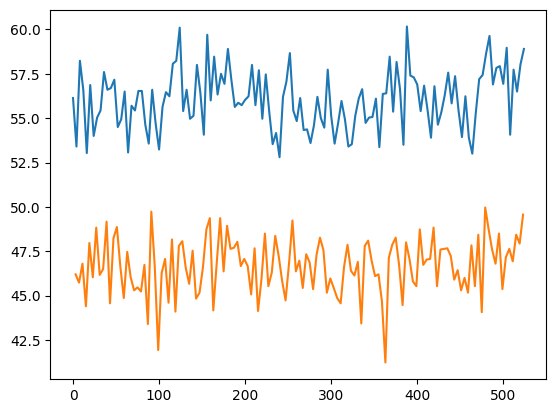

In [13]:
amj_series = seasonal.loc[seasonal["season"] == "AMJ", "tmean (degrees F)"]
ond_series = seasonal.loc[seasonal["season"] == "OND", "tmean (degrees F)"]
plt.plot(amj_series)
plt.plot(ond_series)
D_stat, p_val = stats.ks_2samp(amj_series.values, ond_series.values)
print (D_stat, p_val)

In [14]:
jfm_series = seasonal.loc[seasonal["season"] == "JFM", "tmean (degrees F)"]
jas_series = seasonal.loc[seasonal["season"] == "JAS", "tmean (degrees F)"]


In [15]:
h_stat, p_value = stats.kruskal(jfm_series, amj_series, jas_series, ond_series)
print(h_stat, p_value)

478.54901288044874 2.1242721855680347e-103


-- back to lecture --

### Permutation-test
- back to DJF Nino34

In [16]:
### Define the two periods
early = djf_seasonal.loc[(djf_seasonal["djf_year"] >= 1951) & (djf_seasonal["djf_year"] <= 1980), "nino34"].values
recent = djf_seasonal.loc[(djf_seasonal["djf_year"] >= 1996) & (djf_seasonal["djf_year"] <= 2025), "nino34"].values


In [20]:
Nx, Ny = len(early), len(recent)
N = Nx + Ny
combined = np.concatenate([early, recent])
z_obs, p_asymp = stats.ranksums(early, recent)

perm_z = np.zeros(500)

for i in range(500):
    shuffled = np.random.permutation(combined)
    g1, g2 = shuffled[:Nx], shuffled[Nx:]
    z_i, _ = stats.ranksums(g1, g2)
    perm_z[i] = z_i
### check True (1) and False(0) and the mean will be the probability; two tailed
p_perm = np.mean(np.abs(perm_z) >= np.abs(z_obs))
p_perm

np.float64(0.942)

In [21]:
np.abs(perm_z) >= np.abs(z_obs)

array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,